# Imports

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow import keras
import os
import gc
from tqdm import tqdm
from skimage.measure import find_contours
from tensorflow.keras.models import Sequential, load_model, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,Dropout, Reshape, BatchNormalization, LeakyReLU, Input, Activation
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Segmentación de las imágenes originales

En esta sección se utilizará los datos obtenidos a través de la herramienta roboflow para segmentar las imágenes originales (con un gran número de larvas) en imágenes más pequeñas. Idealmente, todas estas imágenes deberían ser del mismo tamaño y contener una única larva. Dado que ellas se encuentran muy cerca unas de otras, en muchos casos no será posible aislarlas únicamente con este método. Más adelante se desarrollarán algoritmos para solucionar esta problemática.

In [ ]:
def plot_1(imagen, t = "Imagen", color = 'gray'):
  plt.figure(figsize=(7, 7))
  plt.imshow(imagen, vmin=0, vmax=255, cmap = color)
  plt.title(t, fontsize=15)
  plt.axis("off")
  plt.show()
  return

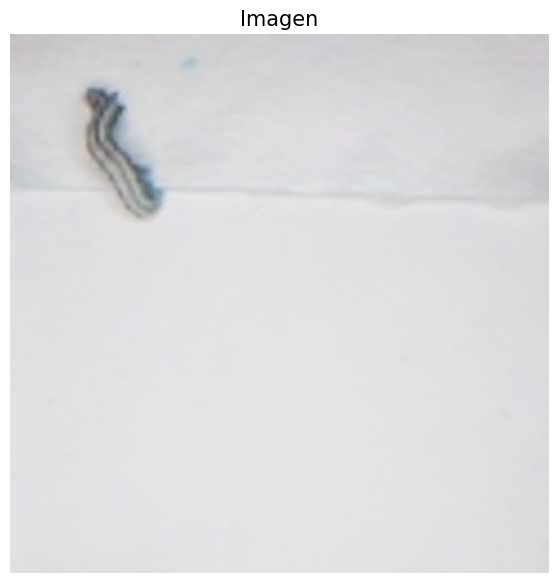

(256, 256, 3)

In [ ]:
directory_path = '/content/drive/MyDrive/Proyecto Final de Carrera/Data-sets/Larvas/Pruebas/'
base_name = 'larva_apta_linea'
image_path = directory_path + base_name + '.jpg'
img = cv2.imread(image_path)
plot_1(img)
img.shape

# Máscaras



## Funciones

In [7]:
# Máscaras Mejoradas para Segmentación de Larvas

IMG_SIZE = 256  # Define el tamaño de las imágenes para el procesamiento

import cv2
import numpy as nph
import matplotlib.pyplot as plt
from tqdm import tqdm

def generate_mask_improved(image, method='combined', min_contour_area=50, target_size=(IMG_SIZE, IMG_SIZE)):
    """
    Genera una máscara binaria mejorada para larvas usando múltiples métodos de segmentación.

    Args:
        image (numpy.ndarray): Imagen de entrada en formato BGR.
        method (str): Método de segmentación ('hsv', 'yuv', 'rgb', 'combined', 'adaptive').
        min_contour_area (int): Área mínima de contornos a considerar.
        target_size (tuple): Tamaño objetivo para redimensionar la máscara.

    Returns:
        numpy.ndarray: Máscara binaria de la larva segmentada.
    """

    # Redimensionar imagen si es necesario
    if image.shape[:2] != target_size:
        image = cv2.resize(image, target_size)

    if method == 'hsv':
        mask = _segment_hsv(image)
    elif method == 'yuv':
        mask = _segment_yuv(image)
    elif method == 'rgb':
        mask = _segment_rgb(image)
    elif method == 'Adaptativo':
        mask = _segment_adaptive(image)
    elif method == 'Combinado':
        mask = _segment_combined(image)
    else:
        raise ValueError("Método no válido. Use: 'hsv', 'yuv', 'rgb', 'adaptive', 'combined'")

    # Post-procesamiento común
    mask = _postprocess_mask(mask, image, min_contour_area)

    return mask


In [9]:
def _segment_hsv(image):
    """Segmentación usando espacio de color HSV optimizado para larvas."""
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Crear múltiples máscaras para diferentes rangos de color de las larvas
    # Rango 1: Larvas con tonos amarillo-verde
    lower1 = np.array([0, 0, 0])    # Hue amarillo, saturación mínima, valor mínimo
    upper1 = np.array([140, 255, 200])  # Hasta verde
    mask1 = cv2.inRange(hsv, lower1, upper1)



    # Combinar ambas máscaras
    mask = mask1

    return mask

def _segment_yuv(image):
    """Segmentación usando espacio de color YUV optimizado para larvas."""
    yuv = cv2.cvtColor(image, cv2.COLOR_BGR2YUV)

    # Basado en las imágenes, la larva es muy visible en los canales U y V
    # La larva aparece con valores específicos en U (azul-cyan) y V (rojo-naranja)

    # Extraer canales
    y, u, v = cv2.split(yuv)

    # Crear máscara basada en los canales U y V donde la larva es más visible
    # En U: la larva aparece con valores altos (hacia cyan/azul)
    # En V: la larva aparece con valores altos (hacia rojo/naranja)

    mask_u = cv2.inRange(u, 135, 255)  # Rango ajustado para canal U
    mask_v = cv2.inRange(v, 100, 125)  # Rango ajustado para canal V

    # Combinar máscaras de U y V
    mask = cv2.bitwise_or(mask_u, mask_v)

    # También considerar casos donde ambos canales están activos, falta logica donde se  considere que ambos estan activos

    return mask

def _segment_rgb(image):
    """Segmentación usando canales RGB mejorada."""
    # Separar canales
    b, g, r = cv2.split(image)

    # Crear máscara inicial
    mask = np.zeros(image.shape[:2], dtype=np.uint8)

    # Calcular estadísticas de la imagen para umbralización adaptativa
    mean_intensity = np.mean(image)

    # La larva generalmente tiene intensidades diferentes al fondo gris uniforme
    # Buscar píxeles que se desvían significativamente del gris uniforme
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Calcular diferencias entre canales (las larvas tienen variación de color)
    diff_rb = np.abs(r.astype(np.int16) - b.astype(np.int16))
    diff_rg = np.abs(r.astype(np.int16) - g.astype(np.int16))
    diff_gb = np.abs(g.astype(np.int16) - b.astype(np.int16))

    # Combinar diferencias
    color_variation = np.maximum(np.maximum(diff_rb, diff_rg), diff_gb)

    # Umbralizar basado en variación de color
    mask[color_variation > 15] = 255

    # También buscar regiones con intensidad específica de larvas
    # Las larvas suelen ser más oscuras que el fondo
    mask_intensity = cv2.inRange(gray, 0, 200)

    # Combinar ambas máscaras
    mask = cv2.bitwise_or(mask, mask_intensity)

    return mask

def _segment_adaptive(image):
    """Segmentación adaptativa mejorada."""
    # Convertir a escala de grises
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Múltiples umbralizaciones adaptativas con diferentes parámetros
    #mask1 = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                 #cv2.THRESH_BINARY_INV, 11, 8)

    mask2 = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                 cv2.THRESH_BINARY_INV, 41, 10)

    #Esto es lo que va en la funcion :
    '''
    adaptiveThreshold(imagen,valor maximo, metodo, tipo de umbral
    ,area de vecindad, constante)
    Como metodo solo existe de media y gaussiana. Haciendo pruebas
    solamente funciona el del tipo de media (al menos con los valores
    propuestos de vecindad y constante)

    Con una constante entre 5 a 10 funciona bien. Con 0 marca todo y
    con 20 solamente marca area muy marcadas como la region mas negra de la
    larva

    En el tipo de umbral simplemente indicamos que queremos que aquellos que
    esten dentro del rango seleccionado se los marque con pixel blanco

    Por ultimo la vecindad minima con la que funciona correctamente es a partir
    de 15, una vecindad menor no funcionara y solo se segmenta una region chica.
    Cualquier vecindad mayor si fuciona, cuanto mayor sea menor espacio vacio
    queda dentro de la larva pero pueden surgir algunos artefactos
    '''


    # Combinar máscaras
    #mask = cv2.bitwise_or(mask1, mask2)
    #Podemos probar de combinar mascaras a ver que pasa tambien pero con el mean
    #ya sale bien

    return mask2

def _segment_combined(image):
    """Segmentación combinada usando múltiples métodos optimizada."""
    # Obtener máscaras de diferentes métodos usando de base la adaptativa
    mask_hsv = _segment_hsv(image)
    mask_yuv = _segment_yuv(image)
    mask_rgb = _segment_rgb(image)
    mask_adaptive = _segment_adaptive(image)

    # Estrategia de combinación más inteligente
    # Dar más peso a YUV ya que muestra mejor contraste
    mask_primary = cv2.bitwise_and(mask_yuv, mask_hsv)

    # Usar RGB y adaptive como apoyo
    mask_secondary = cv2.bitwise_and(mask_rgb, mask_adaptive)

    # Combinar con operación OR
    combined_mask = cv2.bitwise_or(mask_primary, mask_secondary)

    # Aplicar filtro de mediana para reducir ruido
    #combined_mask = cv2.medianBlur(combined_mask, 5)

    return combined_mask

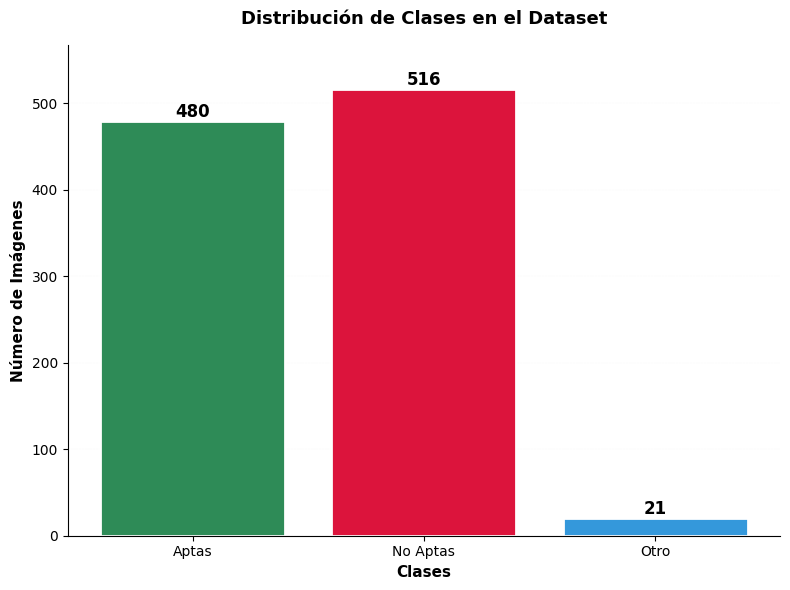

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Datos del dataset
clases = ['Aptas', 'No Aptas', 'Otro']
cantidades = [480, 516, 21]
colores = ['#2E8B57', '#DC143C', '#3498db']  # Verde, Rojo, Azul

# Crear figura con estilo moderno
plt.figure(figsize=(8, 6))
ax = plt.subplot(111)

# Crear barras verticales
bars = ax.bar(clases, cantidades, color=colores, edgecolor='white', linewidth=2)

# Añadir valores encima de las barras
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

# Configurar etiquetas y título
ax.set_xlabel('Clases', fontsize=11, fontweight='bold')
ax.set_ylabel('Número de Imágenes', fontsize=11, fontweight='bold')
ax.set_title('Distribución de Clases en el Dataset',
             fontsize=13, fontweight='bold', pad=15)

# Estilo del gráfico
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.1)
ax.set_axisbelow(True)

# Ajustar límites del eje y
ax.set_ylim(0, max(cantidades) * 1.1)

plt.tight_layout()
plt.show()

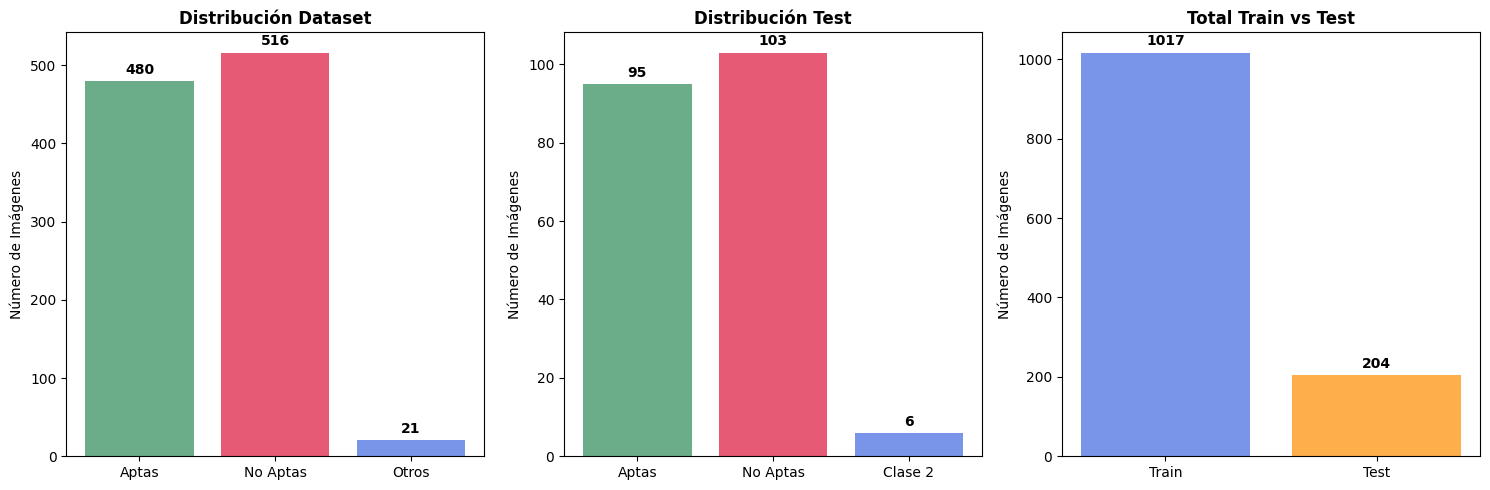

In [ ]:
# Configurar subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Colores para 3 clases
colors = ['#2E8B57', '#DC143C', '#4169E1']  # Verde, Rojo y Azul

# Gráfico 1: Distribución por clase en Train
train_counts = [480, 516, 21]  # Agregada tercera clase
axes[0].bar(['Aptas', 'No Aptas', 'Otros'], train_counts, color=colors, alpha=0.7)
axes[0].set_title('Distribución Dataset', fontweight='bold')
axes[0].set_ylabel('Número de Imágenes')
for i, count in enumerate(train_counts):
    axes[0].text(i, count + max(train_counts)*0.01, str(count),
                ha='center', va='bottom', fontweight='bold')

# Gráfico 2: Distribución por clase en Test
test_counts = [95, 103, 6]  # Agregada tercera clase
axes[1].bar(['Aptas', 'No Aptas', 'Clase 2'], test_counts, color=colors, alpha=0.7)
axes[1].set_title('Distribución Test', fontweight='bold')
axes[1].set_ylabel('Número de Imágenes')
for i, count in enumerate(test_counts):
    axes[1].text(i, count + max(test_counts)*0.01, str(count),
                ha='center', va='bottom', fontweight='bold')

# Gráfico 3: Comparación Train vs Test
total_train = sum(train_counts)
total_test = sum(test_counts)
axes[2].bar(['Train', 'Test'], [total_train, total_test],
            color=['#4169E1', '#FF8C00'], alpha=0.7)
axes[2].set_title('Total Train vs Test', fontweight='bold')
axes[2].set_ylabel('Número de Imágenes')
for i, count in enumerate([total_train, total_test]):
    axes[2].text(i, count + max([total_train, total_test])*0.01, str(count),
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

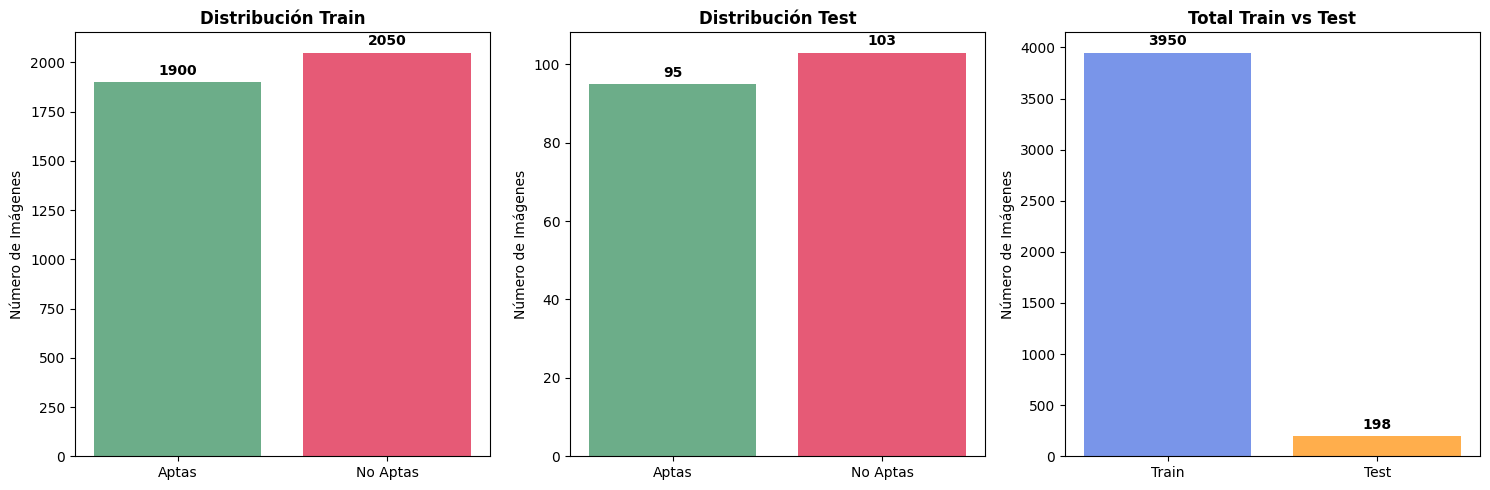

In [ ]:

# Configurar subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Colores
colors = ['#2E8B57', '#DC143C']  # Verde y rojo

# Gráfico 1: Distribución por clase en Train
train_counts = [1900, 2050]
axes[0].bar(['Aptas', 'No Aptas'], train_counts, color=colors, alpha=0.7)
axes[0].set_title('Distribución Train', fontweight='bold')
axes[0].set_ylabel('Número de Imágenes')
for i, count in enumerate(train_counts):
    axes[0].text(i, count + max(train_counts)*0.01, str(count),
                ha='center', va='bottom', fontweight='bold')

# Gráfico 2: Distribución por clase en Test
test_counts = [95, 103]
axes[1].bar(['Aptas', 'No Aptas'], test_counts, color=colors, alpha=0.7)
axes[1].set_title('Distribución Test', fontweight='bold')
axes[1].set_ylabel('Número de Imágenes')
for i, count in enumerate(test_counts):
    axes[1].text(i, count + max(test_counts)*0.01, str(count),
                ha='center', va='bottom', fontweight='bold')

# Gráfico 3: Comparación Train vs Test
total_train = sum(train_counts)
total_test = sum(test_counts)
axes[2].bar(['Train', 'Test'], [total_train, total_test],
            color=['#4169E1', '#FF8C00'], alpha=0.7)
axes[2].set_title('Total Train vs Test', fontweight='bold')
axes[2].set_ylabel('Número de Imágenes')
for i, count in enumerate([total_train, total_test]):
    axes[2].text(i, count + max([total_train, total_test])*0.01, str(count),
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [11]:
def _postprocess_mask(mask, original_image, min_contour_area):
    """Post-procesamiento mejorado de la máscara."""

    # Si la máscara está completamente vacía, intentar con umbralización más permisiva, verificamos si todos los pixeles son negros.
    if np.sum(mask) == 0:
        print("Máscara vacía detectada, aplicando umbralización de emergencia...")
        gray = cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY)
        _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Operaciones morfológicas iniciales para limpiar ruido pequeño
    kernel_small = np.ones((2, 2), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel_small, iterations=1)

    #Morph_open permite hacer erosion, y usamos un kernel chico para eliminar
    #ruidos minimos

    # Encontrar contornos
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    #Queremos buscar unicamente contornos externos (Retr_external)
    #A la vez eliminamos conotrnos redundates con chain_approx_simple ademas
    #de que esta opcion es de menor costo computacional

    if not contours:
        print("No se encontraron contornos válidos")
        return np.zeros_like(mask)

    # Seleccionar el contorno más apropiado
    center = (mask.shape[1] // 2, mask.shape[0] // 2)  #Iniciamos con centro
    #de la imagen
    best_contour = _select_best_contour(contours, center, min_contour_area)

    if best_contour is None:
        print(f"No se encontró contorno con área mínima {min_contour_area}")
        # Intentar con área mínima más pequeña
        best_contour = _select_best_contour(contours, center, min_contour_area // 2)

    if best_contour is None:
        print("No se pudo encontrar ningún contorno válido")
        return mask  # Retornar máscara original si no se encuentra contorno

    # Crear máscara final con el mejor contorno
    final_mask = np.zeros_like(mask)
    cv2.drawContours(final_mask, [best_contour], -1, 255, thickness=cv2.FILLED)
    #Lo que se hace es basicamente es que la mascara y el metodo sirve solamente
    #para darle el molde a la creacion de los contornos, ya que este es el que
    #finalemnte definira la mascara . Para eso llenamos la imagen delimitada
    #por los conotronso (thickness=cv2,FILLED) y le damos un color blanco (255)
    #El indice de jerarquia es -1 ya que por las dudas llenamos todos los
    #contornos.

    # Operaciones morfológicas finales más suaves para preservar la forma
    kernel_medium = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    #Comentar el uso de este kernel: usamos kernel eliptico mas parecido a la
    #figura de una larva
    final_mask = cv2.morphologyEx(final_mask, cv2.MORPH_CLOSE, kernel_medium, iterations=2)
    #Hacemos esto para poder eliminar agujeros negros que nos hayan quedado
    #dentro de nuestro objeto principal, usamos iteration = 2 para asegurarnos
    #de cerrar el agujero;
    final_mask = cv2.dilate(final_mask, kernel_medium, iterations=1)
    #Hacemos un dilate para agrandar la mascara para evitar haber achicado de
    #mas y agrandarla ligeramente

    return final_mask

def _select_best_contour(contours, center, min_area):
    """Selecciona el mejor contorno basado en área y proximidad al centro."""
    best_contour = None
    best_score = float('inf')

    print(f"Evaluando {len(contours)} contornos con área mínima: {min_area}")

    for i, contour in enumerate(contours):
        area = cv2.contourArea(contour)
        print(f"Contorno {i}: área = {area}")

        # Filtrar por área mínima
        if area < min_area:
            continue

        # Calcular centroide
        M = cv2.moments(contour)

        if M['m00'] == 0: #Esto devuelve el Area
            continue


        #Calculo de las posiciones centrales del contorno , segun documentracion
        #de python cv
        cx = int(M['m10'] / M['m00'])
        cy = int(M['m01'] / M['m00'])

        # Calcular distancia al centro
        dist_to_center = np.sqrt((cx - center[0])**2 + (cy - center[1])**2)

        # Score combinado (favorece contornos grandes y cercanos al centro)
        score = dist_to_center / np.sqrt(area)

        print(f"Contorno {i}: centroide=({cx},{cy}), distancia={dist_to_center:.2f}, score={score:.2f}")

        if score < best_score:
            best_score = score
            best_contour = contour

    if best_contour is not None:
        print(f"Mejor contorno seleccionado con score: {best_score:.2f}")

    return best_contour



### Funciones para el manejo de directorios y creacion de imagenes

In [12]:
def load_and_process_single_image(image_path, min_area=50, method='combined'):
    """
    Carga y procesa una única imagen junto con su máscara.
    """
    # Cargar imagen
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"No se pudo cargar la imagen: {image_path}")

    print(f"Procesando imagen: {image_path}")
    print(f"Dimensiones de imagen: {img.shape}")

    # Generar máscara
    mask = generate_mask_improved(img, method=method, min_contour_area=min_area)

    return img, mask


def process_some_images_from_directory(directory_path, base_name, n_min, n_max, min_surface):
    """
    Procesa un rango de imágenes desde un directorio.
    """
    images = []
    masks = []

    for i in range(n_min, n_max):
        image_path = directory_path + base_name + str(i) + '.jpg'
        print(f"Procesando: {image_path}")

        try:
            img, mask = load_and_process_single_image(image_path, min_surface)
            images.append(img)
            masks.append(mask)
        except Exception as e:
            print(f"Error con imagen {image_path}: {e}")
            continue

    return np.array(images), np.array(masks)

# Función adicional para debugging
def debug_mask_generation(image, method='combined', min_area=50):
    """
    Función de debug para entender por qué no se generan máscaras.
    """
    print("=== DEBUG: Generación de Máscaras ===")
    print(f"Dimensiones de imagen: {image.shape}")
    print(f"Rango de valores de imagen: {image.min()} - {image.max()}")

    # Probar cada método individualmente
    methods = ['hsv', 'yuv', 'rgb', 'adaptive']

    for method_name in methods:
        print(f"\n--- Probando método: {method_name} ---")

        if method_name == 'hsv':
            mask = _segment_hsv(image)
        elif method_name == 'yuv':
            mask = _segment_yuv(image)
        elif method_name == 'rgb':
            mask = _segment_rgb(image)
        elif method_name == 'adaptive':
            mask = _segment_adaptive(image)

        white_pixels = np.sum(mask == 255)
        total_pixels = mask.shape[0] * mask.shape[1]
        percentage = (white_pixels / total_pixels) * 100

        print(f"Píxeles blancos: {white_pixels} de {total_pixels} ({percentage:.2f}%)")

        if white_pixels > 0:
            # Encontrar contornos
            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            print(f"Contornos encontrados: {len(contours)}")

            for i, contour in enumerate(contours):
                area = cv2.contourArea(contour)
                print(f"  Contorno {i}: área = {area}")

    print("\n=== Fin del Debug ===")

### Fucniones para visualizacion y datos estattadisticos

In [13]:
def plot_overlay_single(imagen, mask, title="Superposición con Máscara", alpha=0.4):
    """
    Superpone una máscara sobre una imagen con transparencia y bordes destacados.

    Parameters:
    - imagen: Imagen original (BGR o escala de grises)
    - mask: Máscara binaria
    - title: Título de la visualización
    - alpha: Transparencia de la máscara (0-1)
    """
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))

    # Convertir imagen si es BGR
    if len(imagen.shape) == 3:
        imagen_display = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
    else:
        imagen_display = imagen

    # Mostrar imagen original
    ax[0].imshow(imagen_display, cmap='gray' if len(imagen.shape) == 2 else None)
    ax[0].set_title("Imagen Original", fontsize=12)
    ax[0].axis("off")

    # Mostrar imagen con máscara superpuesta
    ax[1].imshow(imagen_display, cmap='gray' if len(imagen.shape) == 2 else None)
    ax[1].imshow(mask, cmap='Reds', alpha=alpha)
    ax[1].set_title(title, fontsize=12)

    # Resaltar bordes de la máscara
    try:
        contours = find_contours(mask, 0.5)
        for contour in contours:
            ax[1].plot(contour[:, 1], contour[:, 0], linewidth=2, color='yellow')
    except:
        pass

    ax[1].axis("off")
    plt.tight_layout()
    plt.show()

def plot_all_methods_comparison(imagen, min_area=50, alpha=0.3):
    """
    Compara todos los métodos de enmascaramiento en una sola visualización.

    Parameters:
    - imagen: Imagen original (BGR)
    - min_area: Área mínima para contornos
    - alpha: Transparencia de las máscaras
    """
    methods = ['hsv', 'yuv', 'rgb', 'Adaptativo', 'Combinado']
    colors = ['Reds', 'Blues', 'Greens', 'Purples', 'Oranges']

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    # Convertir imagen para visualización
    if len(imagen.shape) == 3:
        imagen_display = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
    else:
        imagen_display = imagen

    # Mostrar imagen original
    axes[0].imshow(imagen_display)
    axes[0].set_title('Imagen Original', fontsize=14, fontweight='bold')
    axes[0].axis('off')

    # Procesar cada método
    for i, (method, color) in enumerate(zip(methods, colors)):
        try:
            print(f"Procesando método: {method}")

            # Generar máscara
            mask = generate_mask_improved(imagen, method=method, min_contour_area=min_area)

            # Mostrar superposición
            axes[i+1].imshow(imagen_display)
            axes[i+1].imshow(mask, cmap=color, alpha=alpha)

            # Agregar bordes
            try:
                contours = find_contours(mask, 0.5)
                for contour in contours:
                    axes[i+1].plot(contour[:, 1], contour[:, 0], linewidth=1.5, color='white')
            except:
                pass

            # Calcular estadísticas
            '''
            Esto lo hago para poder saber cuanto ocupa la mascara en relacion
            al total de la imagen. De esta manera podremos decidir que masacara
            es mejor segun cuanto ocupa. Por ejemplo una mascara con menor
            porcentaje podria significar una mascara mas fina y de acorde al
            cuerpo de la larva.
            '''
            white_pixels = np.sum(mask == 255)
            total_pixels = mask.shape[0] * mask.shape[1]
            percentage = (white_pixels / total_pixels) * 100

            axes[i+1].set_title(f'{method.upper()}\n {white_pixels:.0f} pixeles de máscara: {percentage:.1f}% segmentado',
                              fontsize=12, fontweight='bold')
            axes[i+1].axis('off')

            print(f"  - {method}: {white_pixels} píxeles ({percentage:.2f}%)")

        except Exception as e:
            print(f"Error con método {method}: {e}")
            axes[i+1].text(0.5, 0.5, f'Error\n{method}', ha='center', va='center',
                          transform=axes[i+1].transAxes, fontsize=12)
            axes[i+1].axis('off')

    plt.tight_layout()
    plt.show()

def plot_method_detailed(imagen, method='combined', min_area=50):
    """
    Visualización detallada de un método específico mostrando el proceso paso a paso.
    Se elige algno de los metodos que se quiere analizar y se muestra
    la mascara inicial y luego la mascara final para ver como se modifica
    la misma con el uso de las modifciaciones morfologicas
    Parameters:
    - imagen: Imagen original (BGR)
    - method: Método a analizar
    - min_area: Área mínima para contornos
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    # Convertir imagen para visualización
    if len(imagen.shape) == 3:
        imagen_display = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
    else:
        imagen_display = imagen

    # 1. Imagen original
    axes[0,0].imshow(imagen_display)
    axes[0,0].set_title('1. Imagen Original', fontsize=12, fontweight='bold')
    axes[0,0].axis('off')

    try:
        # 2. Obtener máscara inicial (antes del post-procesamiento)
        if method == 'hsv':
            mask_initial = _segment_hsv(imagen)
            color_space = cv2.cvtColor(imagen, cv2.COLOR_BGR2HSV)
        elif method == 'yuv':
            mask_initial = _segment_yuv(imagen)
            color_space = cv2.cvtColor(imagen, cv2.COLOR_BGR2YUV)
        elif method == 'rgb':
            mask_initial = _segment_rgb(imagen)
            color_space = imagen.copy()
        elif method == 'Adaptativo':
            mask_initial = _segment_adaptive(imagen)
            color_space = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
        else:  # combined
            mask_initial = _segment_combined(imagen)
            color_space = imagen.copy()

        # 3. Espacio de color utilizado
        if method in ['hsv', 'yuv']:
            axes[0,1].imshow(color_space)
        elif method == 'Adaptativo':
            axes[0,1].imshow(color_space, cmap='gray')
        else:
            axes[0,1].imshow(cv2.cvtColor(color_space, cv2.COLOR_BGR2RGB))
        axes[0,1].set_title(f'2. Espacio {method.upper()}', fontsize=12, fontweight='bold')
        axes[0,1].axis('off')

        # 4. Máscara inicial
        axes[0,2].imshow(mask_initial, cmap='gray')
        initial_pixels = np.sum(mask_initial == 255)
        initial_percent = (initial_pixels / (mask_initial.shape[0] * mask_initial.shape[1])) * 100
        axes[0,2].set_title(f'3. Máscara Inicial\n{initial_percent:.1f}%', fontsize=12, fontweight='bold')
        axes[0,2].axis('off')

        # 5. Máscara final (con post-procesamiento)
        mask_final = generate_mask_improved(imagen, method=method, min_contour_area=min_area)
        axes[1,0].imshow(mask_final, cmap='gray')
        final_pixels = np.sum(mask_final == 255)
        final_percent = (final_pixels / (mask_final.shape[0] * mask_final.shape[1])) * 100
        axes[1,0].set_title(f'4. Máscara Final\n{final_percent:.1f}%', fontsize=12, fontweight='bold')
        axes[1,0].axis('off')

        # 6. Superposición con bordes
        axes[1,1].imshow(imagen_display)
        axes[1,1].imshow(mask_final, cmap='Reds', alpha=0.4)
        try:
            contours = find_contours(mask_final, 0.5)
            for contour in contours:
                axes[1,1].plot(contour[:, 1], contour[:, 0], linewidth=2, color='yellow')
        except:
            pass
        axes[1,1].set_title('5. Superposición Final', fontsize=12, fontweight='bold')
        axes[1,1].axis('off')

        # 7. Área segmentada aislada
        masked_image = imagen_display.copy()
        if len(masked_image.shape) == 3:
            for i in range(3):
                masked_image[:,:,i] = masked_image[:,:,i] * (mask_final / 255)
        else:
            masked_image = masked_image * (mask_final / 255)

        axes[1,2].imshow(masked_image)
        axes[1,2].set_title('6. Área Segmentada', fontsize=12, fontweight='bold')
        axes[1,2].axis('off')

        # Estadísticas
        print(f"\n=== Estadísticas para método {method.upper()} ===")
        print(f"Píxeles iniciales: {initial_pixels} ({initial_percent:.2f}%)")
        print(f"Píxeles finales: {final_pixels} ({final_percent:.2f}%)")
        print(f"Reducción: {((initial_pixels - final_pixels) / initial_pixels * 100):.1f}%" if initial_pixels > 0 else "N/A")

    except Exception as e:
        print(f"Error procesando método {method}: {e}")
        for ax in axes.flatten()[1:]:
            ax.text(0.5, 0.5, f'Error\n{str(e)[:50]}...', ha='center', va='center',
                   transform=ax.transAxes, fontsize=10)
            ax.axis('off')

    plt.suptitle(f'Análisis Detallado - Método {method.upper()}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

def compare_masks_side_by_side(imagen, methods=['rgb', 'adaptive', 'combined'], min_area=50):
    """
    Compara métodos específicos lado a lado con sus máscaras y superposiciones.
    Principamente se busca comprar rgb, adaptive y combined que fueron los
    mejores

    Parameters:
    - imagen: Imagen original (BGR)
    - methods: Lista de métodos a comparar
    - min_area: Área mínima para contornos
    """
    n_methods = len(methods)
    fig, axes = plt.subplots(3, n_methods + 1, figsize=(5*(n_methods+1), 15))

    if n_methods == 1:
        axes = axes.reshape(-1, 1)

    # Convertir imagen para visualización
    imagen_display = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB) if len(imagen.shape) == 3 else imagen

    # Primera fila: Imagen original + máscaras
    axes[0,0].imshow(imagen_display)
    axes[0,0].set_title('Imagen Original', fontsize=12, fontweight='bold')
    axes[0,0].axis('off')

    masks = []
    for i, method in enumerate(methods):
        try:
            mask = generate_mask_improved(imagen, method=method, min_contour_area=min_area)
            masks.append(mask)

            axes[0,i+1].imshow(mask, cmap='gray')
            white_pixels = np.sum(mask == 255)
            percentage = (white_pixels / (mask.shape[0] * mask.shape[1])) * 100
            axes[0,i+1].set_title(f'Máscara {method.upper()}\n{percentage:.1f}%',
                                fontsize=12, fontweight='bold')
            axes[0,i+1].axis('off')
        except Exception as e:
            print(f"Error con {method}: {e}")
            masks.append(np.zeros((imagen.shape[0], imagen.shape[1]), dtype=np.uint8))

    # Segunda fila: Superposiciones
    axes[1,0].imshow(imagen_display)
    axes[1,0].set_title('Referencia', fontsize=12, fontweight='bold')
    axes[1,0].axis('off')

    colors = ['Reds', 'Blues', 'Greens', 'Purples', 'Oranges']
    for i, (method, mask) in enumerate(zip(methods, masks)):
        axes[1,i+1].imshow(imagen_display)
        axes[1,i+1].imshow(mask, cmap=colors[i % len(colors)], alpha=0.4)
        try:
            contours = find_contours(mask, 0.5)
            for contour in contours:
                axes[1,i+1].plot(contour[:, 1], contour[:, 0], linewidth=1.5, color='white')
        except:
            pass
        axes[1,i+1].set_title(f'Superposición {method.upper()}', fontsize=12, fontweight='bold')
        axes[1,i+1].axis('off')

    # Tercera fila: Áreas segmentadas
    axes[2,0].axis('off')  # Espacio vacío

    for i, (method, mask) in enumerate(zip(methods, masks)):
        masked_image = imagen_display.copy()
        if len(masked_image.shape) == 3:
            for j in range(3):
                masked_image[:,:,j] = masked_image[:,:,j] * (mask / 255)
        else:
            masked_image = masked_image * (mask / 255)

        axes[2,i+1].imshow(masked_image)
        axes[2,i+1].set_title(f'Segmentado {method.upper()}', fontsize=12, fontweight='bold')
        axes[2,i+1].axis('off')

    plt.tight_layout()
    plt.show()

In [14]:
def plot_all_methods_comparison(imagen, min_area=50, alpha=0.3):
    """
    Compara todos los métodos de enmascaramiento en una sola visualización.

    Parameters:
    - imagen: Imagen original (BGR)
    - min_area: Área mínima para contornos
    - alpha: Transparencia de las máscaras
    """
    methods = ['hsv', 'yuv', 'rgb', 'Adaptativo']
    colors = ['Reds', 'Blues', 'Greens', 'Purples']

    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    axes = axes.flatten()

    # Convertir imagen para visualización
    if len(imagen.shape) == 3:
        imagen_display = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
    else:
        imagen_display = imagen

    # Mostrar imagen original


    # Procesar cada método
    for i, (method, color) in enumerate(zip(methods, colors)):
        try:
            print(f"Procesando método: {method}")

            # Generar máscara
            mask = generate_mask_improved(imagen, method=method, min_contour_area=min_area)

            # Mostrar superposición
            axes[i].imshow(imagen_display)
            axes[i].imshow(mask, cmap=color, alpha=alpha)

            # Agregar bordes
            try:
                contours = find_contours(mask, 0.5)
                for contour in contours:
                    axes[i].plot(contour[:, 1], contour[:, 0], linewidth=1.5, color='white')
            except:
                pass

            # Calcular estadísticas
            '''
            Esto lo hago para poder saber cuanto ocupa la mascara en relacion
            al total de la imagen. De esta manera podremos decidir que masacara
            es mejor segun cuanto ocupa. Por ejemplo una mascara con menor
            porcentaje podria significar una mascara mas fina y de acorde al
            cuerpo de la larva.
            '''
            white_pixels = np.sum(mask == 255)
            total_pixels = mask.shape[0] * mask.shape[1]
            percentage = (white_pixels / total_pixels) * 100

            axes[i].set_title(f'{method.upper()}\n {white_pixels:.0f} pixeles de máscara: {percentage:.1f}% segmentado',
                              fontsize=12, fontweight='bold')
            axes[i].axis('off')

            print(f"  - {method}: {white_pixels} píxeles ({percentage:.2f}%)")

        except Exception as e:
            print(f"Error con método {method}: {e}")
            axes[i].text(0.5, 0.5, f'Error\n{method}', ha='center', va='center',
                          transform=axes[i+1].transAxes, fontsize=12)
            axes[i].axis('off')

    plt.tight_layout()
    plt.show()

Procesando método: hsv
Evaluando 7 contornos con área mínima: 50
Contorno 0: área = 2.0
Contorno 1: área = 1.0
Contorno 2: área = 1198.5
Contorno 2: centroide=(51,57), distancia=104.74, score=3.03
Contorno 3: área = 1.0
Contorno 4: área = 4.0
Contorno 5: área = 5.0
Contorno 6: área = 96.5
Contorno 6: centroide=(8,6), distancia=171.13, score=17.42
Mejor contorno seleccionado con score: 3.03
  - hsv: 1657 píxeles (2.53%)
Procesando método: yuv
Evaluando 3 contornos con área mínima: 50
Contorno 0: área = 42.0
Contorno 1: área = 8.0
Contorno 2: área = 407.0
Contorno 2: centroide=(43,61), distancia=108.23, score=5.36
Mejor contorno seleccionado con score: 5.36
  - yuv: 855 píxeles (1.30%)
Procesando método: rgb
Evaluando 12 contornos con área mínima: 50
Contorno 0: área = 2.0
Contorno 1: área = 1.0
Contorno 2: área = 10.0
Contorno 3: área = 61.5
Contorno 3: centroide=(252,68), distancia=137.75, score=17.57
Contorno 4: área = 1468.0
Contorno 4: centroide=(52,56), distancia=104.69, score=2.73

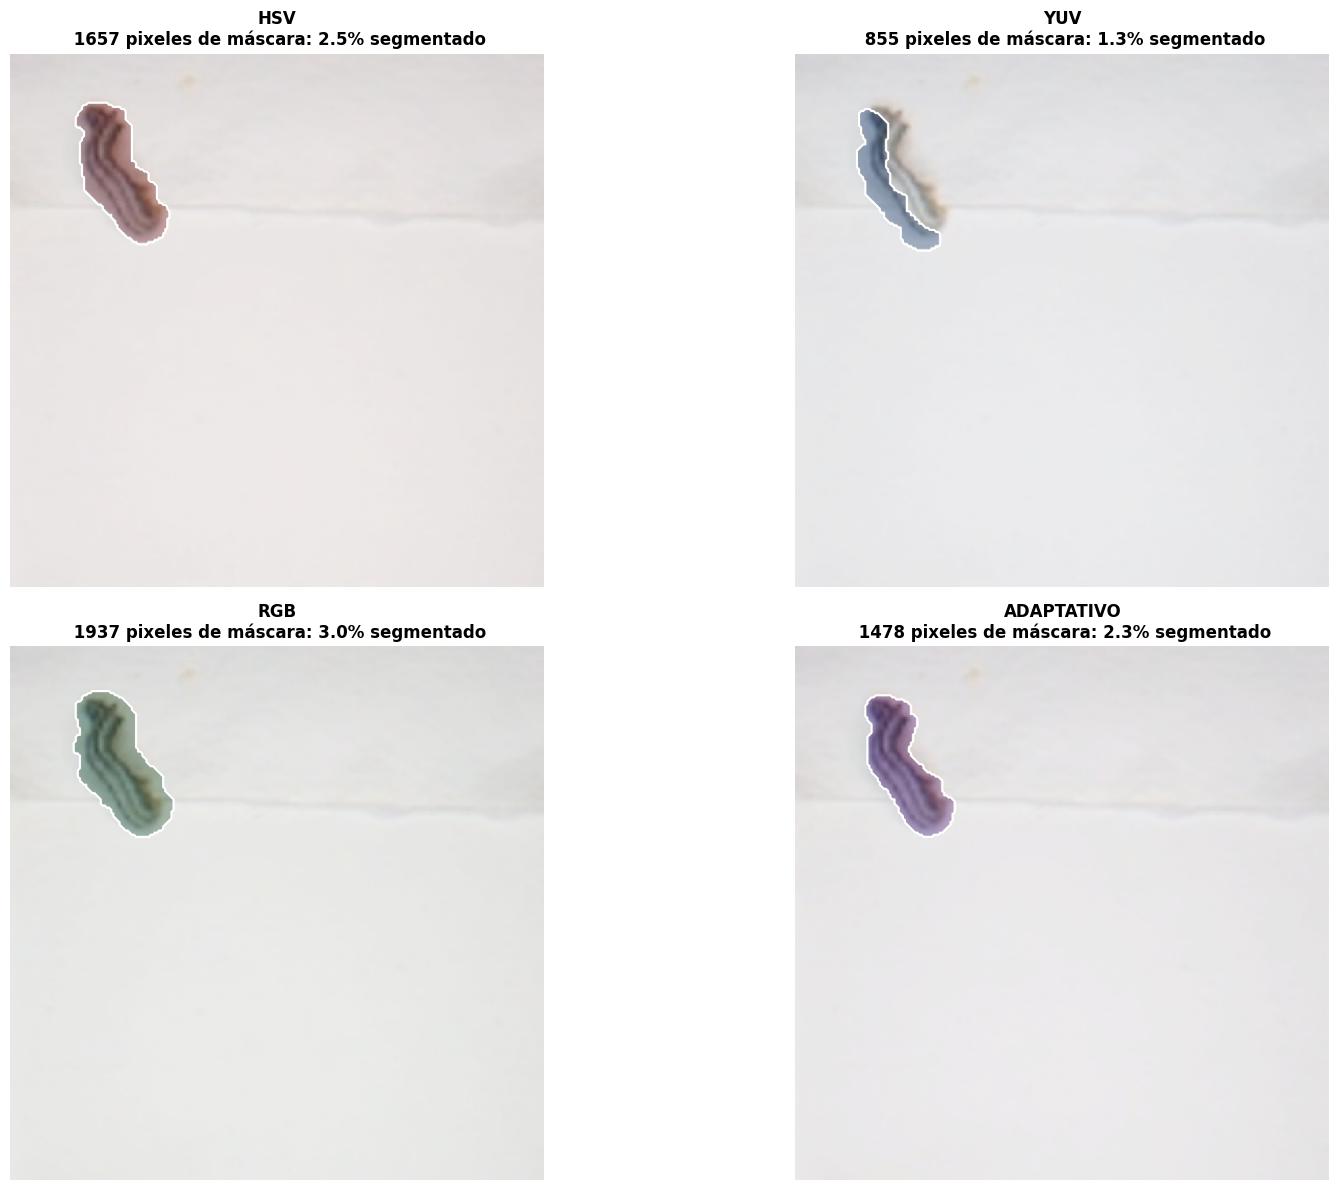

In [ ]:
plot_all_methods_comparison(img)

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def visualize_postprocessing_stepwise(image, min_contour_area=50):
    """
    Visualización paso a paso del post-procesamiento morfológico de larvas,
    mostrando imágenes individuales y métricas de contornos para documentación académica.
    """
    # Paso 1: Imagen original
    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("Paso 1: Imagen original")
    plt.axis('off')
    plt.show()

    # Paso 2: Máscara inicial combinada
    mask_init = _segment_adaptive(image)
    plt.figure(figsize=(6,6))
    plt.imshow(mask_init, cmap='gray')
    plt.title("Paso 2: Máscara inicial combinada")
    plt.axis('off')
    plt.show()

    # Paso 3: Apertura (eliminación de ruido pequeño)
    kernel_small = np.ones((2,2), np.uint8)
    mask_opened = cv2.morphologyEx(mask_init, cv2.MORPH_OPEN, kernel_small, iterations=1)
    plt.figure(figsize=(6,6))
    plt.imshow(mask_opened, cmap='gray')
    plt.title("Paso 3: Apertura (ruido eliminado)")
    plt.axis('off')
    plt.show()

    # Paso 4: Contornos detectados con centroides y score
    contours, _ = cv2.findContours(mask_opened, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask_contours = cv2.cvtColor(mask_opened, cv2.COLOR_GRAY2BGR)
    center = (mask_opened.shape[1]//2, mask_opened.shape[0]//2)
    metrics = []

    for i, cnt in enumerate(contours):
        area = cv2.contourArea(cnt)
        M = cv2.moments(cnt)
        if M['m00'] == 0:
            continue
        cx = int(M['m10']/M['m00'])
        cy = int(M['m01']/M['m00'])
        dist_to_center = np.sqrt((cx - center[0])**2 + (cy - center[1])**2)
        score = dist_to_center / np.sqrt(area)
        metrics.append({"Contorno": i, "Área": area, "Centroid X": cx, "Centroid Y": cy,
                        "Distancia al centro": dist_to_center, "Score": score})
        # Dibujar contorno y centroide con leyenda
        cv2.drawContours(mask_contours, [cnt], -1, (0,255,0), 1)
        cv2.circle(mask_contours, (cx, cy), 4, (255,0,0), -1)
        cv2.putText(mask_contours, f"S:{score:.2f}", (cx+5, cy-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 1)

    plt.figure(figsize=(6,6))
    plt.imshow(mask_contours)
    plt.title("Paso 4: Contornos detectados y centroides\nVerde: contorno, Rojo: centroide, Azul: score")
    plt.axis('off')
    plt.show()

    # Mostrar tabla de métricas
    metrics_df = pd.DataFrame(metrics)
    print("Tabla de métricas de contornos detectados:")
    display(metrics_df)

    # Paso 5: Selección del mejor contorno
    best_contour = _select_best_contour(contours, center, min_contour_area)
    mask_best = np.zeros_like(mask_opened)
    if best_contour is not None:
        cv2.drawContours(mask_best, [best_contour], -1, 255, thickness=cv2.FILLED)

    plt.figure(figsize=(6,6))
    plt.imshow(mask_best, cmap='gray')
    plt.title("Paso 5: Mejor contorno seleccionado (larva principal)")
    plt.axis('off')
    plt.show()

    # Paso 6: Cierre morfológico y dilatación
    kernel_medium = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    final_mask = cv2.morphologyEx(mask_best, cv2.MORPH_CLOSE, kernel_medium, iterations=2)
    final_mask = cv2.dilate(final_mask, kernel_medium, iterations=1)

    plt.figure(figsize=(6,6))
    plt.imshow(final_mask, cmap='gray')
    plt.title("Paso 6: Máscara final (cerrada y dilatada)")
    plt.axis('off')
    plt.show()

    # Paso 7: Máscara final sobrepuesta a la imagen original
    overlay = image.copy()
    overlay[final_mask==255] = [0,255,0]  # resaltar larva en verde
    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title("Paso 7: Máscara final sobre imagen original (larva resaltada en verde)")
    plt.axis('off')
    plt.show()

    # Paso 8: Centroides y área del mejor contorno
    if best_contour is not None:
        M = cv2.moments(best_contour)
        cx = int(M['m10']/M['m00'])
        cy = int(M['m01']/M['m00'])
        area = cv2.contourArea(best_contour)
        plt.figure(figsize=(6,6))
        display_img = cv2.cvtColor(image.copy(), cv2.COLOR_BGR2RGB)
        plt.imshow(display_img)
        plt.scatter(cx, cy, color='red', s=50)
        plt.title(f"Paso 8: Centroide y área del mejor contorno\nÁrea: {area:.1f} px")
        plt.axis('off')
        plt.show()


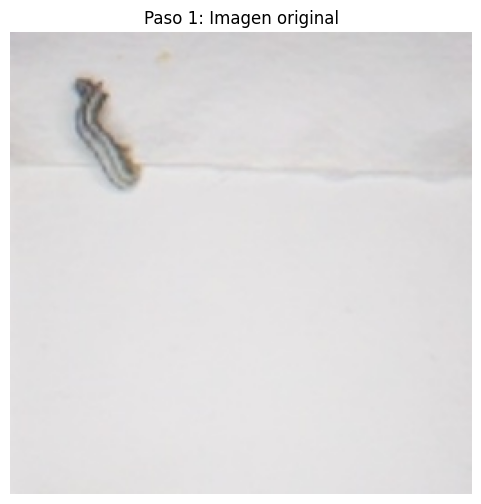

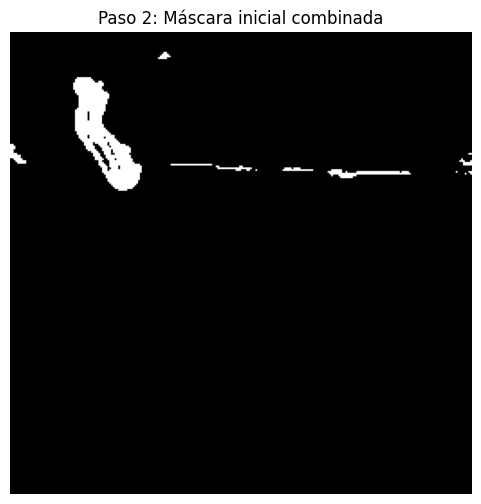

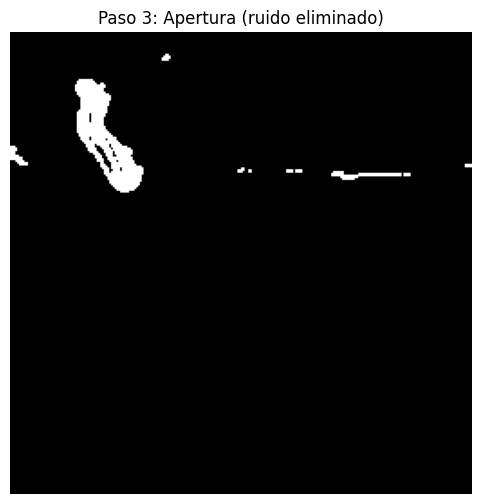

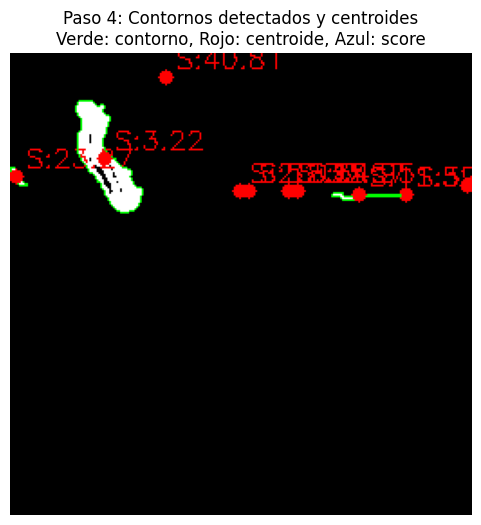

Tabla de métricas de contornos detectados:


,Contorno,Área,Centroid X,Centroid Y,Distancia al centro,Score
0,0,3.0,219,78,103.831594,59.947199
1,1,52.5,193,78,82.006097,11.317917
2,2,3.0,159,76,60.539243,34.952349
3,3,3.0,154,76,58.137767,33.565856
4,4,1.0,132,76,52.153619,52.153619
5,5,4.0,127,76,52.009614,26.004807
6,6,3.0,253,73,136.565003,78.845841
7,7,35.5,3,68,138.654246,23.271212
8,8,1029.5,52,58,103.324731,3.220261
9,9,9.0,86,13,122.429572,40.809857


Evaluando 10 contornos con área mínima: 50
Contorno 0: área = 3.0
Contorno 1: área = 52.5
Contorno 1: centroide=(193,78), distancia=82.01, score=11.32
Contorno 2: área = 3.0
Contorno 3: área = 3.0
Contorno 4: área = 1.0
Contorno 5: área = 4.0
Contorno 6: área = 3.0
Contorno 7: área = 35.5
Contorno 8: área = 1029.5
Contorno 8: centroide=(52,58), distancia=103.32, score=3.22
Contorno 9: área = 9.0
Mejor contorno seleccionado con score: 3.22


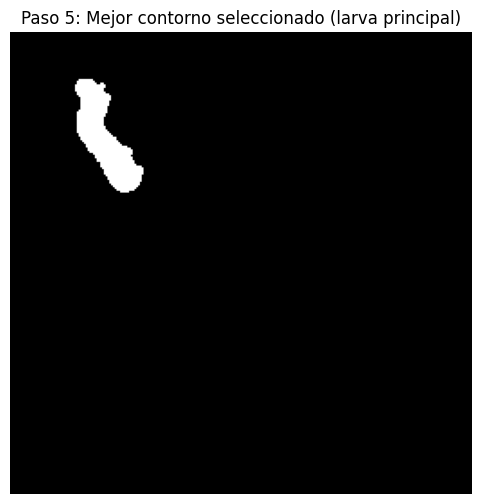

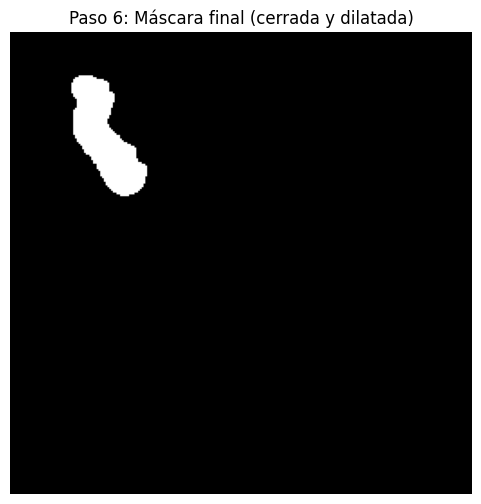

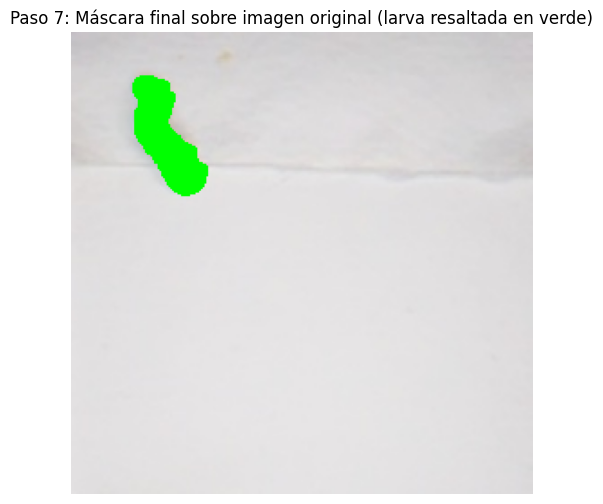

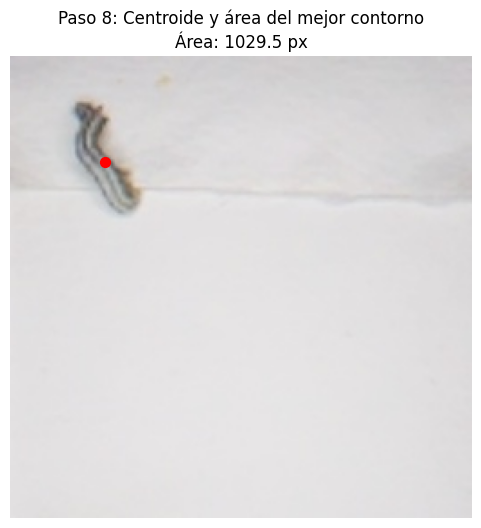

In [ ]:
visualize_postprocessing_stepwise(img)

### Visualizacion de Imagenes

In [ ]:
debug_mask_generation(img)

=== DEBUG: Generación de Máscaras ===
Dimensiones de imagen: (256, 256, 3)
Rango de valores de imagen: 67 - 234

--- Probando método: hsv ---
Píxeles blancos: 1415 de 65536 (2.16%)
Contornos encontrados: 13
  Contorno 0: área = 0.0
  Contorno 1: área = 5.0
  Contorno 2: área = 0.0
  Contorno 3: área = 0.0
  Contorno 4: área = 1.0
  Contorno 5: área = 1205.0
  Contorno 6: área = 0.0
  Contorno 7: área = 1.0
  Contorno 8: área = 0.0
  Contorno 9: área = 2.0
  Contorno 10: área = 2.0
  Contorno 11: área = 0.0
  Contorno 12: área = 89.5

--- Probando método: yuv ---
Píxeles blancos: 570 de 65536 (0.87%)
Contornos encontrados: 3
  Contorno 0: área = 43.0
  Contorno 1: área = 9.0
  Contorno 2: área = 409.5

--- Probando método: rgb ---
Píxeles blancos: 2144 de 65536 (3.27%)
Contornos encontrados: 21
  Contorno 0: área = 3.5
  Contorno 1: área = 0.0
  Contorno 2: área = 0.0
  Contorno 3: área = 2.5
  Contorno 4: área = 4.0
  Contorno 5: área = 73.0
  Contorno 6: área = 1470.5
  Contorno 7: ár

Para visualizar el proceso de enmascaramiento, puedes modificar la función `process_and_analyze_folder` para guardar o mostrar las imágenes en cada etapa clave. Aquí te presento un esquema general de cómo podrías hacerlo:

1.  **Cargar la imagen original**: Muestra la imagen cargada.
2.  **Preprocesamiento**: Muestra el resultado de pasos como el ajuste de contraste, la ecualización del histograma, etc.
3.  **Umbralización o Segmentación**: Muestra la imagen binaria o segmentada donde la máscara es visible.
4.  **Operaciones Morfológicas**: Muestra el resultado de aplicar operaciones como erosión o dilatación para refinar la máscara.
5.  **Detección de Contornos**: Muestra la imagen con los contornos detectados.
6.  **Selección del Contorno Principal**: Muestra la imagen con el contorno seleccionado.
7.  **Creación de la Máscara Final**: Muestra la máscara final obtenida.

Para lograr esto, dentro de tu función de procesamiento de imágenes, puedes guardar las imágenes intermedias en un directorio temporal o utilizar funciones de visualización si estás trabajando en un entorno interactivo.

Aquí te presento cómo podrías modificar tu código (considerando que utilizas OpenCV y Matplotlib, que son comunes para estas tareas) para mostrar las imágenes intermedias en un bucle:

Procesando método: hsv
Evaluando 7 contornos con área mínima: 50
Contorno 0: área = 2.0
Contorno 1: área = 1.0
Contorno 2: área = 1198.5
Contorno 2: centroide=(51,57), distancia=104.74, score=3.03
Contorno 3: área = 1.0
Contorno 4: área = 4.0
Contorno 5: área = 5.0
Contorno 6: área = 96.5
Contorno 6: centroide=(8,6), distancia=171.13, score=17.42
Mejor contorno seleccionado con score: 3.03
  - hsv: 1657 píxeles (2.53%)
Procesando método: yuv
Evaluando 3 contornos con área mínima: 50
Contorno 0: área = 42.0
Contorno 1: área = 8.0
Contorno 2: área = 407.0
Contorno 2: centroide=(43,61), distancia=108.23, score=5.36
Mejor contorno seleccionado con score: 5.36
  - yuv: 855 píxeles (1.30%)
Procesando método: rgb
Evaluando 12 contornos con área mínima: 50
Contorno 0: área = 2.0
Contorno 1: área = 1.0
Contorno 2: área = 10.0
Contorno 3: área = 61.5
Contorno 3: centroide=(252,68), distancia=137.75, score=17.57
Contorno 4: área = 1468.0
Contorno 4: centroide=(52,56), distancia=104.69, score=2.73

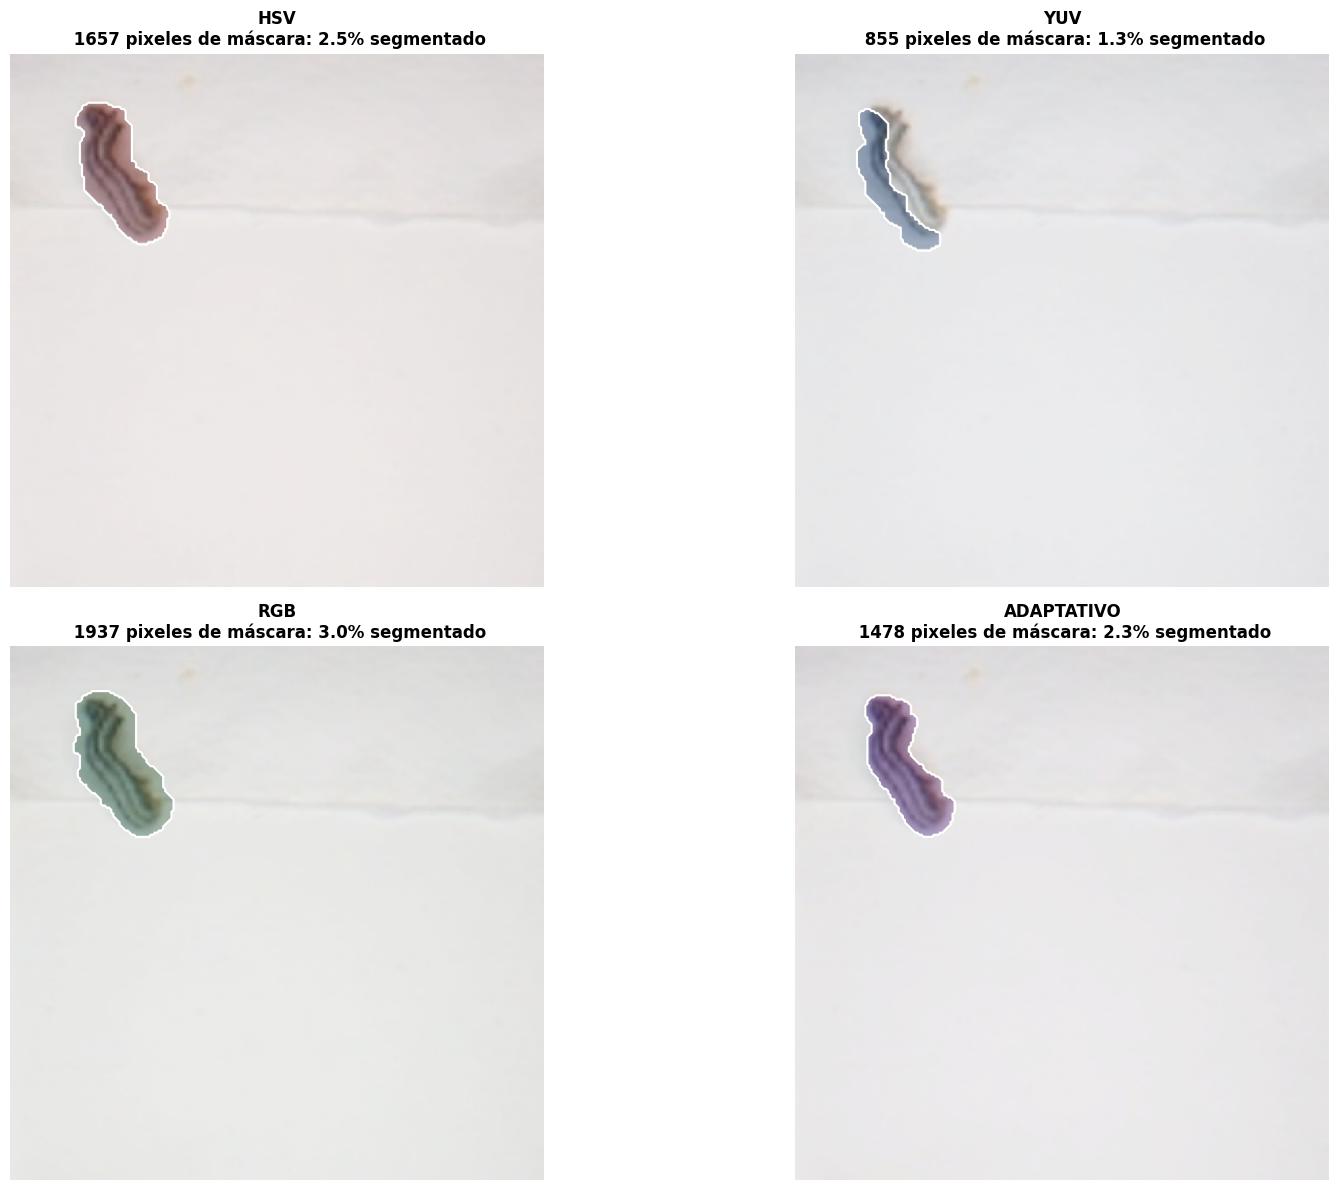

In [ ]:
plot_all_methods_comparison(img, min_area=50, alpha=0.3)

Evaluando 10 contornos con área mínima: 50
Contorno 0: área = 3.0
Contorno 1: área = 52.5
Contorno 1: centroide=(193,78), distancia=82.01, score=11.32
Contorno 2: área = 3.0
Contorno 3: área = 3.0
Contorno 4: área = 1.0
Contorno 5: área = 4.0
Contorno 6: área = 3.0
Contorno 7: área = 35.5
Contorno 8: área = 1029.5
Contorno 8: centroide=(52,58), distancia=103.32, score=3.22
Contorno 9: área = 9.0
Mejor contorno seleccionado con score: 3.22

=== Estadísticas para método ADAPTATIVO ===
Píxeles iniciales: 1315 (2.01%)
Píxeles finales: 1478 (2.26%)
Reducción: -12.4%


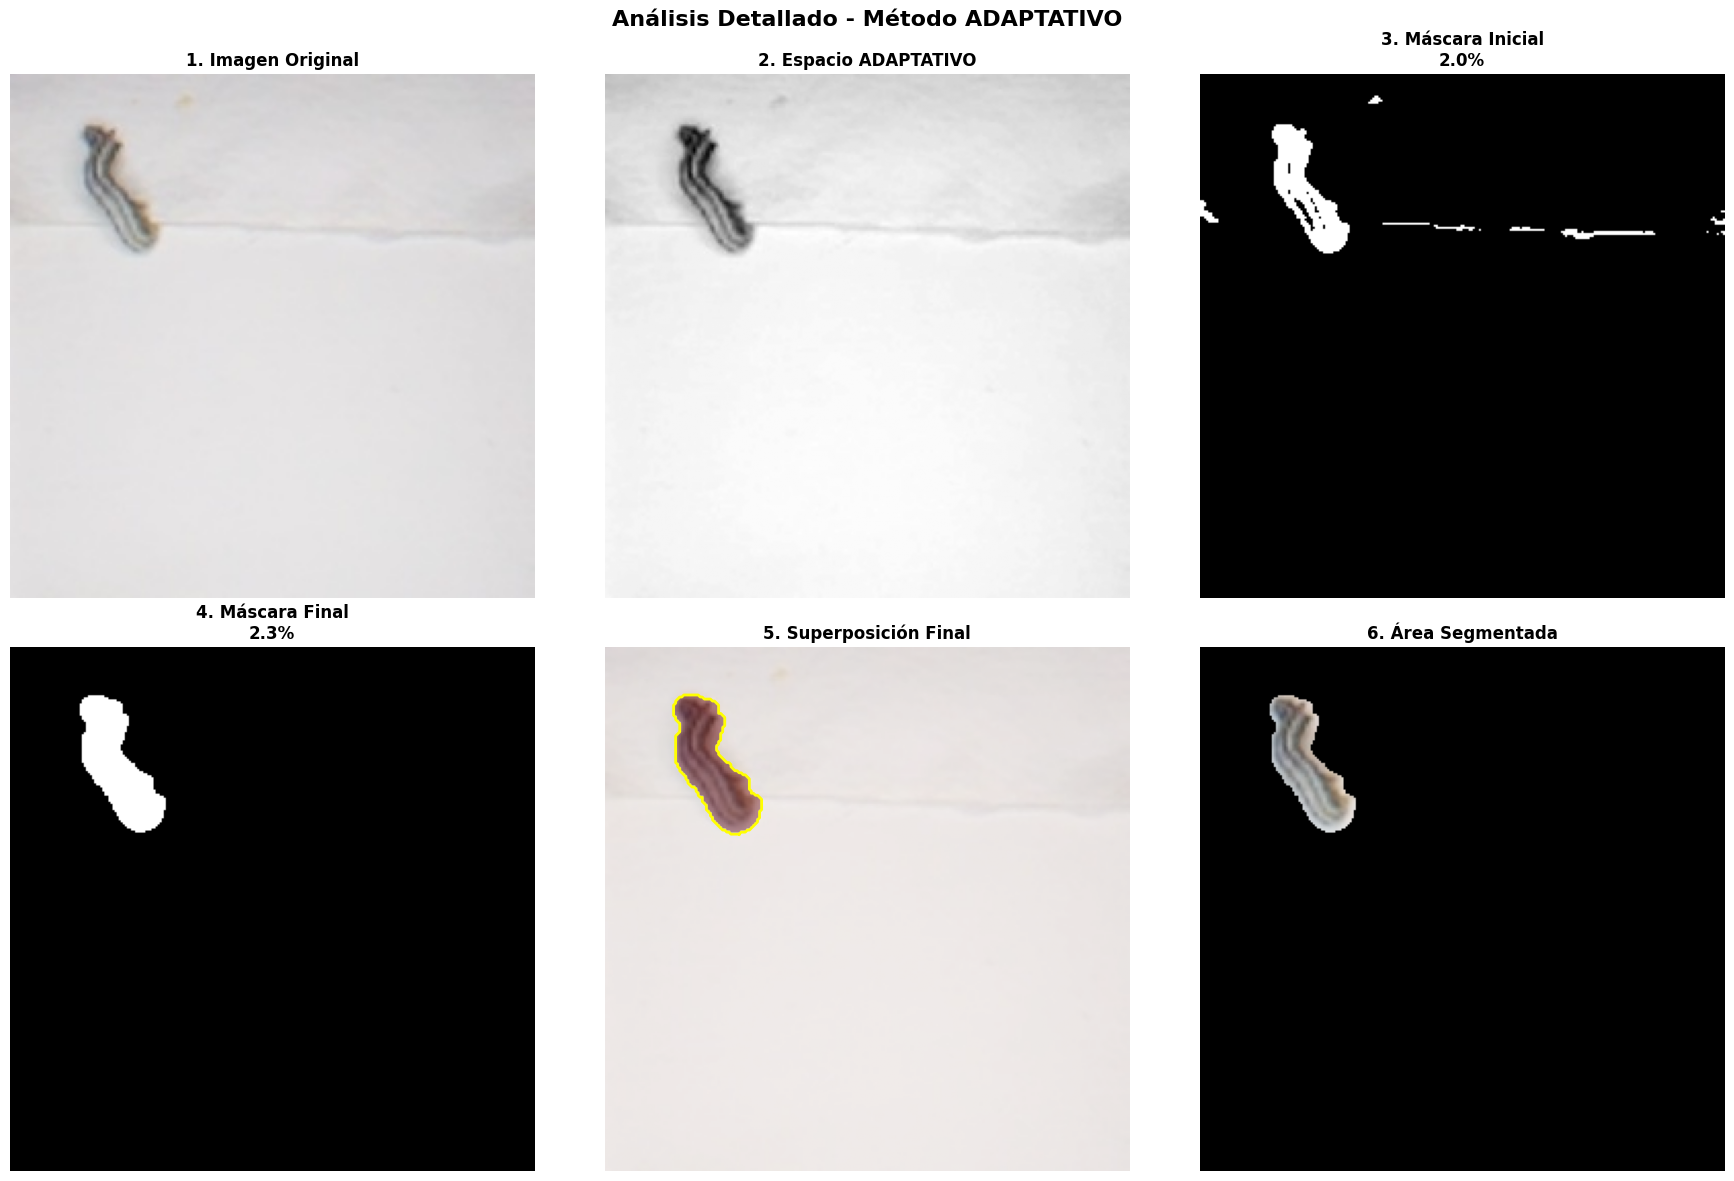

In [ ]:
plot_method_detailed(img, method='Adaptativo', min_area=50)

### Funciones pero de carga y guardado de imagenes

## Ejemplos de imágenes y sus máscaras

Se crean mascaras que sean lo suficientemente vulgares para poder contener a toda la larva y no perder caracteristicas como pueden ser la cabeza o patas. Podemos ver que gran parte de las larvas son enmascaradas de manera correcta aunque hay alguna que se segmentaron de manera incompleta o de manera cortada

Por otro lado un desafio a enfrentar es que al normalizar la dimension de la segmentación en muchos casos nos encontramos que la imagen segmentada posee mas de una larva, haciendo que en la mascara se marcasen todas. Por esta razón en el codigo se implemento una logica que solamente se conserve la mascara de aquella que estuviese mas cercano al centro de la imagen

## Guardado de archivos

Una vez generadas las máscaras, para cada imagen guardamos dos archivos: la máscara y la imagen enmascarada. Esta última surge de una operación AND entre la máscara y la imagen original, preservando la larva en un fondo negro. Estas imágenes serán los datos de entrada de la CNN, por lo que también se genera un archivo .csv con los nombres de las imágenes y su etiqueta.

In [16]:
def process_folder_with_masks(input_folder_path, output_folder_path, crop_size=128, method='Adaptativo', min_area=50):
    """
    Procesa todas las imágenes de una carpeta, genera máscaras, recorta 128x128 centrado en el centroide
    y guarda las imágenes enmascaradas (fondo negro + área de la larva).

    Parameters:
    - input_folder_path: Ruta de la carpeta con las imágenes originales
    - output_folder_path: Ruta donde guardar las imágenes procesadas
    - crop_size: Tamaño del recorte (default 128x128)
    - method: Método de enmascaramiento a usar
    - min_area: Área mínima para considerar contornos válidos

    Returns:
    - areas_list: Lista con las áreas de todas las máscaras procesadas
    - processed_count: Número de imágenes procesadas exitosamente
    - error_list: Lista de imágenes que no se pudieron procesar
    """

    # Crear carpeta de salida si no existe
    os.makedirs(output_folder_path, exist_ok=True)

    # Obtener lista de archivos de imagen
    valid_extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff']
    image_files = []

    for file in os.listdir(input_folder_path):
        if any(file.lower().endswith(ext) for ext in valid_extensions):
            image_files.append(file)

    if not image_files:
        print("No se encontraron imágenes en la carpeta especificada.")
        return [], 0, []

    print(f"Encontradas {len(image_files)} imágenes para procesar.")

    areas_list = []
    processed_count = 0
    error_list = []
    half_crop = crop_size // 2

    # Procesar cada imagen
    for filename in tqdm(image_files, desc="Procesando imágenes"):
        try:
            # Cargar imagen
            image_path = os.path.join(input_folder_path, filename)
            img = cv2.imread(image_path)

            if img is None:
                print(f"No se pudo cargar: {filename}")
                error_list.append(filename)
                continue

            # Generar máscara
            mask = generate_mask_improved(img, method=method, min_contour_area=min_area)

            # Verificar que la máscara no esté vacía
            if np.sum(mask) == 0:
                print(f"Máscara vacía para: {filename}")
                error_list.append(filename)
                continue

            # Encontrar contornos para obtener el centroide
            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            if not contours:
                print(f"No se encontraron contornos en: {filename}")
                error_list.append(filename)
                continue

            # Seleccionar el contorno principal (el de mayor área)
            main_contour = max(contours, key=cv2.contourArea)
            area = cv2.contourArea(main_contour)

            # Calcular centroide del contorno principal
            M = cv2.moments(main_contour)
            if M['m00'] == 0:
                print(f"No se pudo calcular centroide para: {filename}")
                error_list.append(filename)
                continue

            cx = int(M['m10'] / M['m00'])
            cy = int(M['m01'] / M['m00'])

            # Definir límites del recorte centrado en el centroide
            y_start = max(0, cy - half_crop)
            y_end = min(img.shape[0], cy + half_crop)
            x_start = max(0, cx - half_crop)
            x_end = min(img.shape[1], cx + half_crop)

            # Ajustar si el recorte se sale de los límites
            if y_end - y_start < crop_size:
                if y_start == 0:
                    y_end = min(img.shape[0], crop_size)
                else:
                    y_start = max(0, img.shape[0] - crop_size)

            if x_end - x_start < crop_size:
                if x_start == 0:
                    x_end = min(img.shape[1], crop_size)
                else:
                    x_start = max(0, img.shape[1] - crop_size)

            # Recortar imagen y máscara
            img_cropped = img[y_start:y_end, x_start:x_end]
            mask_cropped = mask[y_start:y_end, x_start:x_end]

            # Redimensionar a exactamente 128x128 si es necesario
            if img_cropped.shape[:2] != (crop_size, crop_size):
                img_cropped = cv2.resize(img_cropped, (crop_size, crop_size))
                mask_cropped = cv2.resize(mask_cropped, (crop_size, crop_size))

            # Crear imagen enmascarada (fondo negro + área de la larva)
            masked_image = np.zeros_like(img_cropped)

            # Aplicar máscara a cada canal
            for i in range(3):  # Para BGR
                masked_image[:, :, i] = img_cropped[:, :, i] * (mask_cropped / 255.0)

            # Guardar imagen procesada
            name_without_ext = os.path.splitext(filename)[0]
            output_filename = f"{name_without_ext}_masked.jpg"
            output_path = os.path.join(output_folder_path, output_filename)

            cv2.imwrite(output_path, masked_image)

            # Guardar área (calculada sobre la máscara original, no recortada)
            areas_list.append(area)
            processed_count += 1

        except Exception as e:
            print(f"Error procesando {filename}: {str(e)}")
            error_list.append(filename)
            continue

    print(f"\nProcesamiento completado:")
    print(f"- Imágenes procesadas exitosamente: {processed_count}")
    print(f"- Imágenes con errores: {len(error_list)}")

    if error_list:
        print("Archivos con errores:", error_list[:5], "..." if len(error_list) > 5 else "")

    return areas_list, processed_count, error_list


def calculate_mask_statistics(areas_list, show_plot=True):
    """
    Calcula estadísticas de las áreas de las máscaras y muestra visualizaciones.

    Parameters:
    - areas_list: Lista de áreas calculadas
    - show_plot: Si mostrar gráficos estadísticos

    Returns:
    - stats_dict: Diccionario con todas las estadísticas
    """

    if not areas_list:
        print("No hay datos de áreas para calcular estadísticas.")
        return {}

    areas_array = np.array(areas_list)

    # Calcular estadísticas
    stats = {
        'total_images': len(areas_list),
        'min_area': np.min(areas_array),
        'max_area': np.max(areas_array),
        'mean_area': np.mean(areas_array),
        'median_area': np.median(areas_array),
        'std_area': np.std(areas_array),
        'q25': np.percentile(areas_array, 25),
        'q75': np.percentile(areas_array, 75)
    }

    # Mostrar estadísticas
    print("\n" + "="*50)
    print("ESTADÍSTICAS DE ÁREAS DE MÁSCARAS")
    print("="*50)
    print(f"Total de imágenes procesadas: {stats['total_images']}")
    print(f"Área mínima: {stats['min_area']:.2f} píxeles")
    print(f"Área máxima: {stats['max_area']:.2f} píxeles")
    print(f"Área promedio: {stats['mean_area']:.2f} píxeles")
    print(f"Área mediana: {stats['median_area']:.2f} píxeles")
    print(f"Desviación estándar: {stats['std_area']:.2f} píxeles")
    print(f"Cuartil 25%: {stats['q25']:.2f} píxeles")
    print(f"Cuartil 75%: {stats['q75']:.2f} píxeles")
    print(f"Rango (max-min): {stats['max_area'] - stats['min_area']:.2f} píxeles")
    print("="*50)

    if show_plot:
        # Crear visualizaciones
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        # Histograma
        axes[0,0].hist(areas_array, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
        axes[0,0].axvline(stats['mean_area'], color='red', linestyle='--',
                         label=f'Media: {stats["mean_area"]:.1f}')
        axes[0,0].axvline(stats['median_area'], color='green', linestyle='--',
                         label=f'Mediana: {stats["median_area"]:.1f}')
        axes[0,0].set_title('Distribución de Áreas de Máscaras')
        axes[0,0].set_xlabel('Área (píxeles)')
        axes[0,0].set_ylabel('Frecuencia')
        axes[0,0].legend()
        axes[0,0].grid(True, alpha=0.3)

        # Box plot
        axes[0,1].boxplot(areas_array, vert=True)
        axes[0,1].set_title('Box Plot de Áreas')
        axes[0,1].set_ylabel('Área (píxeles)')
        axes[0,1].grid(True, alpha=0.3)

        # Gráfico de línea (evolución)
        axes[1,0].plot(range(len(areas_array)), areas_array, 'b-', alpha=0.6)
        axes[1,0].axhline(stats['mean_area'], color='red', linestyle='--',
                         label=f'Media: {stats["mean_area"]:.1f}')
        axes[1,0].set_title('Evolución de Áreas por Imagen')
        axes[1,0].set_xlabel('Índice de Imagen')
        axes[1,0].set_ylabel('Área (píxeles)')
        axes[1,0].legend()
        axes[1,0].grid(True, alpha=0.3)

        # Estadísticas resumidas (texto)
        axes[1,1].axis('off')
        stats_text = f"""
RESUMEN ESTADÍSTICO

Número de imágenes: {stats['total_images']}

Área mínima: {stats['min_area']:.1f} px
Área máxima: {stats['max_area']:.1f} px
Área promedio: {stats['mean_area']:.1f} px

Mediana: {stats['median_area']:.1f} px
Desv. estándar: {stats['std_area']:.1f} px

Q25: {stats['q25']:.1f} px
Q75: {stats['q75']:.1f} px

Rango: {stats['max_area'] - stats['min_area']:.1f} px
        """
        axes[1,1].text(0.1, 0.9, stats_text, transform=axes[1,1].transAxes,
                      fontsize=12, verticalalignment='top',
                      bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"))

        plt.tight_layout()
        plt.show()

    return stats


def process_and_analyze_folder(input_folder, output_folder, crop_size=128, method='Adaptativo', min_area=50):
    """
    Función combinada que procesa las imágenes y calcula estadísticas en un solo paso.

    Parameters:
    - input_folder: Carpeta con imágenes originales
    - output_folder: Carpeta donde guardar imágenes procesadas
    - crop_size: Tamaño del recorte
    - method: Método de enmascaramiento
    - min_area: Área mínima para contornos

    Returns:
    - stats_dict: Diccionario con estadísticas
    """

    print("Iniciando procesamiento de imágenes...")
    areas, processed_count, errors = process_folder_with_masks(
        input_folder, output_folder, crop_size, method, min_area
    )

    print("\nCalculando estadísticas...")
    stats = calculate_mask_statistics(areas, show_plot=True)

    return stats

In [4]:
ls -1 '/content/drive/MyDrive/Proyecto Final de Carrera/photos/Apto' | wc -l

479


In [5]:
ls -1 '/content/drive/MyDrive/Proyecto Final de Carrera/photos/No-Apta' | wc -l

514


Iniciando procesamiento de imágenes...
Encontradas 479 imágenes para procesar.


Procesando imágenes:   0%|          | 2/479 [00:00<00:25, 18.38it/s]

Evaluando 3 contornos con área mínima: 50
Contorno 0: área = 14.0
Contorno 1: área = 2.0
Contorno 2: área = 858.0
Contorno 2: centroide=(80,107), distancia=52.39, score=1.79
Mejor contorno seleccionado con score: 1.79
Evaluando 4 contornos con área mínima: 50
Contorno 0: área = 852.5
Contorno 0: centroide=(105,131), distancia=23.19, score=0.79
Contorno 1: área = 2.0
Contorno 2: área = 1.0
Contorno 3: área = 3.5
Mejor contorno seleccionado con score: 0.79
Evaluando 5 contornos con área mínima: 50
Contorno 0: área = 7.5
Contorno 1: área = 3.5
Contorno 2: área = 724.5
Contorno 2: centroide=(88,90), distancia=55.17, score=2.05
Contorno 3: área = 2.0
Contorno 4: área = 28.5
Mejor contorno seleccionado con score: 2.05
Evaluando 3 contornos con área mínima: 50
Contorno 0: área = 62.0
Contorno 0: centroide=(110,184), distancia=58.82, score=7.47
Contorno 1: área = 72.5
Contorno 1: centroide=(91,177), distancia=61.40, score=7.21
Contorno 2: área = 859.5
Contorno 2: centroide=(129,149), distancia

Procesando imágenes:   2%|▏         | 8/479 [00:00<00:11, 40.20it/s]

Evaluando 2 contornos con área mínima: 50
Contorno 0: área = 1024.5
Contorno 0: centroide=(145,163), distancia=38.91, score=1.22
Contorno 1: área = 8.0
Mejor contorno seleccionado con score: 1.22
Evaluando 6 contornos con área mínima: 50
Contorno 0: área = 0.0
Contorno 1: área = 40.5
Contorno 2: área = 1022.0
Contorno 2: centroide=(120,99), distancia=30.08, score=0.94
Contorno 3: área = 1.0
Contorno 4: área = 13.0
Contorno 5: área = 1.0
Mejor contorno seleccionado con score: 0.94
Evaluando 2 contornos con área mínima: 50
Contorno 0: área = 1.0
Contorno 1: área = 953.0
Contorno 1: centroide=(112,95), distancia=36.67, score=1.19
Mejor contorno seleccionado con score: 1.19
Evaluando 13 contornos con área mínima: 50
Contorno 0: área = 10.0
Contorno 1: área = 1.0
Contorno 2: área = 1.0
Contorno 3: área = 9.5
Contorno 4: área = 21.0
Contorno 5: área = 7.5
Contorno 6: área = 2.0
Contorno 7: área = 269.5
Contorno 7: centroide=(127,131), distancia=3.16, score=0.19
Contorno 8: área = 18.0
Contor

...

Evaluando 1 contornos con área mínima: 50
Contorno 0: área = 747.5
Contorno 0: centroide=(179,78), distancia=71.42, score=2.61
Mejor contorno seleccionado con score: 2.61
Evaluando 6 contornos con área mínima: 50
Contorno 0: área = 2.0
Contorno 1: área = 1.0
Contorno 2: área = 17.0
Contorno 3: área = 790.0
Contorno 3: centroide=(173,96), distancia=55.22, score=1.96
Contorno 4: área = 56.0
Contorno 4: centroide=(5,62), distancia=139.59, score=18.65
Contorno 5: área = 54.0
Contorno 5: centroide=(6,14), distancia=166.97, score=22.72
Mejor contorno seleccionado con score: 1.96
Evaluando 6 contornos con área mínima: 50
Contorno 0: área = 1.0
Contorno 1: área = 3.0
Contorno 2: área = 1.0
Contorno 3: área = 5.0
Contorno 4: área = 889.0
Contorno 4: centroide=(147,64), distancia=66.76, score=2.24
Contorno 5: área = 108.5
Contorno 5: centroide=(9,27), distancia=156.08, score=14.98
Mejor contorno seleccionado con score: 2.24
Evaluando 2 contornos con área mínima: 50
Contorno 0: área = 1.0
Contorn

Procesando imágenes:  99%|█████████▉| 476/479 [00:11<00:00, 46.65it/s]

Evaluando 2 contornos con área mínima: 50
Contorno 0: área = 1157.0
Contorno 0: centroide=(82,159), distancia=55.47, score=1.63
Contorno 1: área = 21.0
Mejor contorno seleccionado con score: 1.63
Evaluando 4 contornos con área mínima: 50
Contorno 0: área = 2.0
Contorno 1: área = 3.0
Contorno 2: área = 1183.0
Contorno 2: centroide=(157,41), distancia=91.71, score=2.67
Contorno 3: área = 136.5
Contorno 3: centroide=(9,35), distancia=151.03, score=12.93
Mejor contorno seleccionado con score: 2.67
Evaluando 6 contornos con área mínima: 50
Contorno 0: área = 1296.5
Contorno 0: centroide=(153,208), distancia=83.82, score=2.33
Contorno 1: área = 2.0
Contorno 2: área = 71.0
Contorno 2: centroide=(4,120), distancia=124.26, score=14.75
Contorno 3: área = 9.0
Contorno 4: área = 7.0
Contorno 5: área = 99.0
Contorno 5: centroide=(120,2), distancia=126.25, score=12.69
Mejor contorno seleccionado con score: 2.33
Evaluando 5 contornos con área mínima: 50
Contorno 0: área = 254.0
Contorno 0: centroide=

Procesando imágenes: 100%|██████████| 479/479 [00:11<00:00, 41.47it/s]


Evaluando 14 contornos con área mínima: 50
Contorno 0: área = 2.0
Contorno 1: área = 11.0
Contorno 2: área = 3.0
Contorno 3: área = 8.0
Contorno 4: área = 29.0
Contorno 5: área = 2.0
Contorno 6: área = 18.0
Contorno 7: área = 1.0
Contorno 8: área = 1.0
Contorno 9: área = 1.0
Contorno 10: área = 16.5
Contorno 11: área = 10.0
Contorno 12: área = 9.0
Contorno 13: área = 856.0
Contorno 13: centroide=(186,111), distancia=60.44, score=2.07
Mejor contorno seleccionado con score: 2.07

Procesamiento completado:
- Imágenes procesadas exitosamente: 479
- Imágenes con errores: 0

Calculando estadísticas...

ESTADÍSTICAS DE ÁREAS DE MÁSCARAS
Total de imágenes procesadas: 479
Área mínima: 803.50 píxeles
Área máxima: 1946.00 píxeles
Área promedio: 1352.84 píxeles
Área mediana: 1364.50 píxeles
Desviación estándar: 196.21 píxeles
Cuartil 25%: 1234.25 píxeles
Cuartil 75%: 1486.00 píxeles
Rango (max-min): 1142.50 píxeles


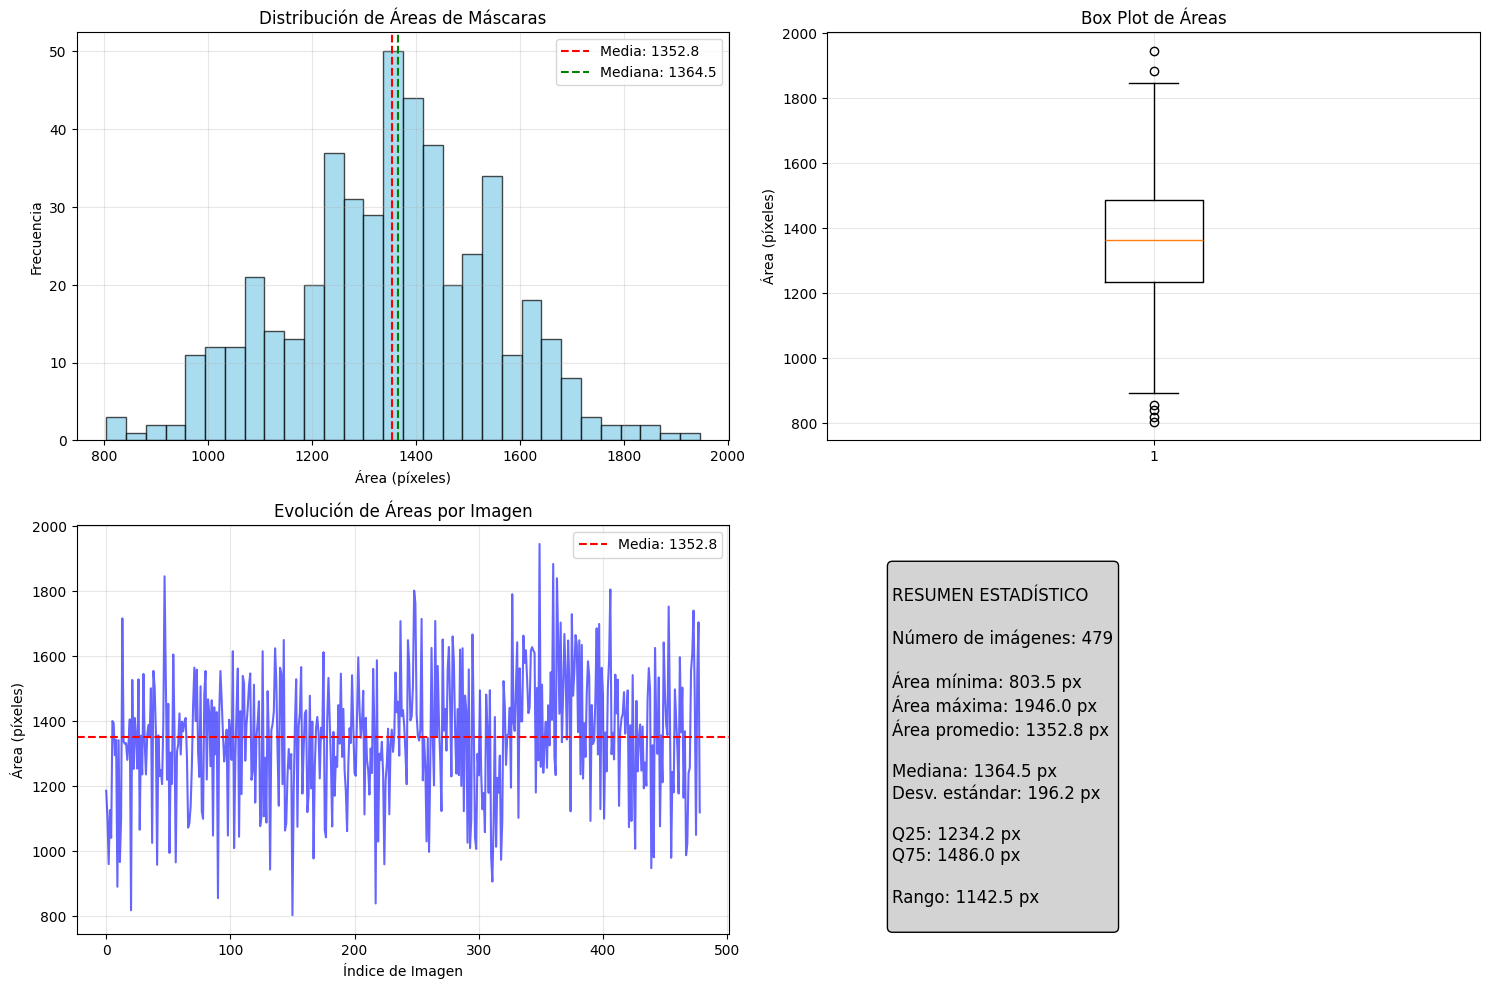

In [17]:
input_path = '/content/drive/MyDrive/Proyecto Final de Carrera/photos/Apto'
output_path = '/content/drive/MyDrive/Proyecto Final de Carrera/Data-sets/Larvas/Enmascarada-Aptas/Prueba(Borrar)'


# Opción 1: Procesar y analizar todo en un paso
stats = process_and_analyze_folder(input_path, output_path)

Iniciando procesamiento de imágenes...
Encontradas 514 imágenes para procesar.


Procesando imágenes:   0%|          | 0/514 [00:00<?, ?it/s]

Evaluando 2 contornos con área mínima: 50
Contorno 0: área = 808.5
Contorno 0: centroide=(118,78), distancia=50.99, score=1.79
Contorno 1: área = 17.5
Mejor contorno seleccionado con score: 1.79


Procesando imágenes:   0%|          | 1/514 [00:00<06:05,  1.41it/s]

Evaluando 4 contornos con área mínima: 50
Contorno 0: área = 2.0
Contorno 1: área = 4.0
Contorno 2: área = 1267.5
Contorno 2: centroide=(93,87), distancia=53.91, score=1.51
Contorno 3: área = 29.0
Mejor contorno seleccionado con score: 1.51


...

Evaluando 7 contornos con área mínima: 50
Contorno 0: área = 776.5
Contorno 0: centroide=(59,142), distancia=70.41, score=2.53
Contorno 1: área = 1.0
Contorno 2: área = 3.0
Contorno 3: área = 2.0
Contorno 4: área = 1.0
Contorno 5: área = 4.0
Contorno 6: área = 12.0
Mejor contorno seleccionado con score: 2.53


Procesando imágenes: 100%|█████████▉| 513/514 [02:39<00:00,  1.62it/s]

Evaluando 9 contornos con área mínima: 50
Contorno 0: área = 7.5
Contorno 1: área = 4.0
Contorno 2: área = 30.0
Contorno 3: área = 18.0
Contorno 4: área = 2.0
Contorno 5: área = 16.5
Contorno 6: área = 2.0
Contorno 7: área = 7.5
Contorno 8: área = 827.0
Contorno 8: centroide=(103,92), distancia=43.83, score=1.52
Mejor contorno seleccionado con score: 1.52


Procesando imágenes: 100%|██████████| 514/514 [02:40<00:00,  3.21it/s]



Procesamiento completado:
- Imágenes procesadas exitosamente: 514
- Imágenes con errores: 0

Calculando estadísticas...

ESTADÍSTICAS DE ÁREAS DE MÁSCARAS
Total de imágenes procesadas: 514
Área mínima: 128.00 píxeles
Área máxima: 2228.50 píxeles
Área promedio: 1295.87 píxeles
Área mediana: 1224.00 píxeles
Desviación estándar: 451.03 píxeles
Cuartil 25%: 926.75 píxeles
Cuartil 75%: 1722.88 píxeles
Rango (max-min): 2100.50 píxeles


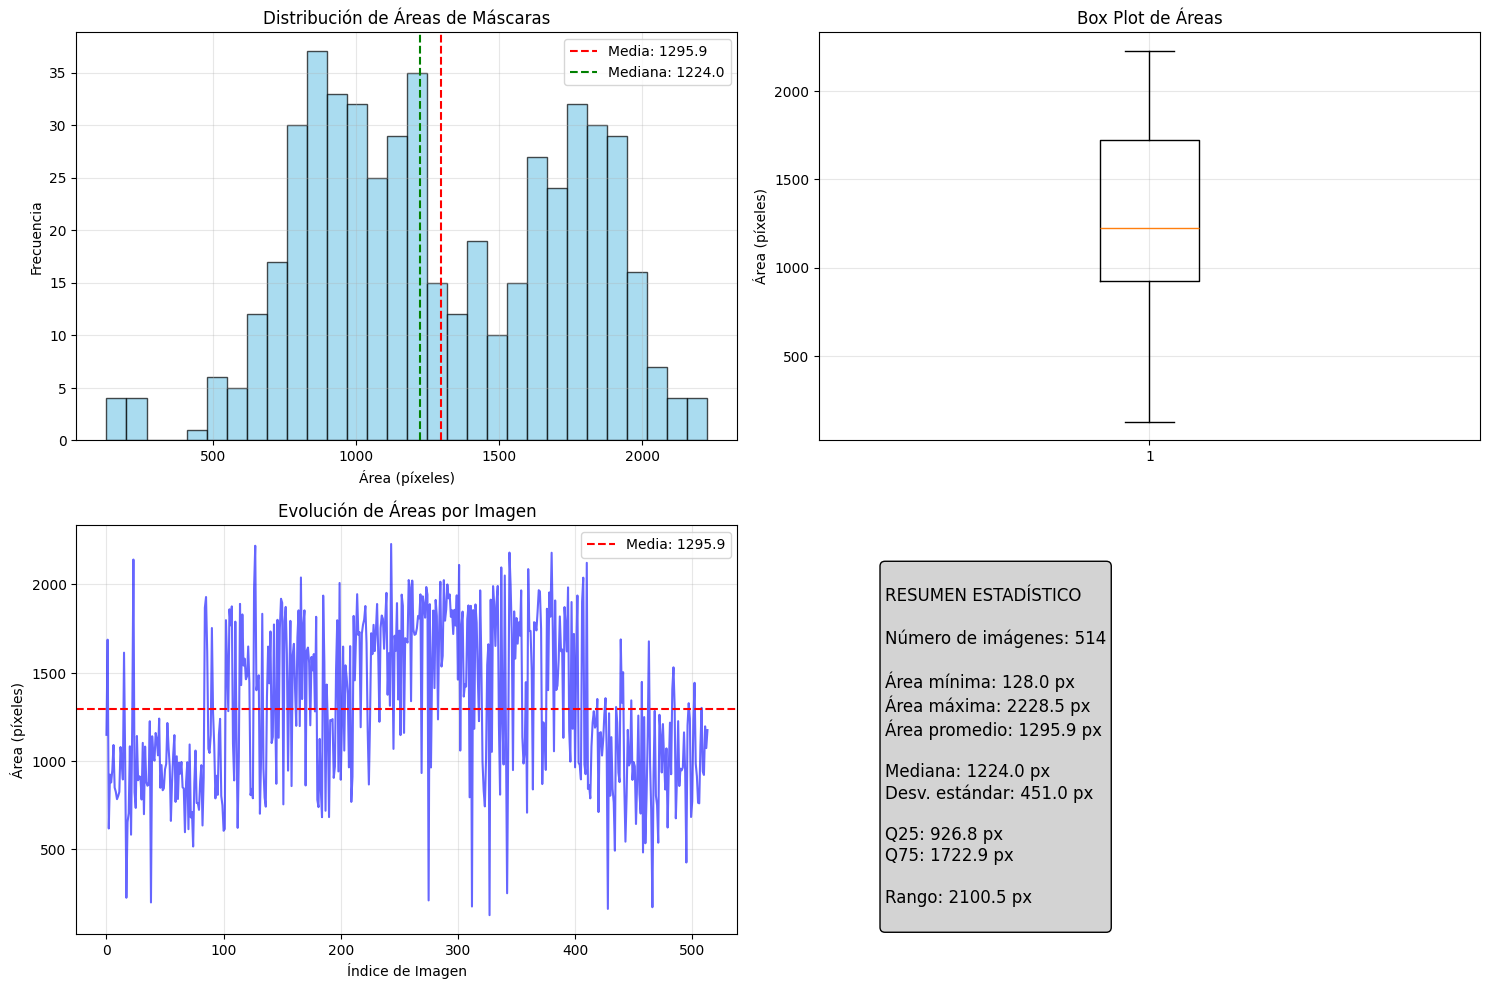

In [ ]:
input_path = '/content/drive/MyDrive/Proyecto Final de Carrera/photos/No-Apta'
output_path = '/content/drive/MyDrive/Proyecto Final de Carrera/Data-sets/Larvas/Enmascarada-No-Aptas2'


# Opción 1: Procesar y analizar todo en un paso
stats = process_and_analyze_folder(input_path, output_path)